In [17]:
# NBVAL_SKIP
import os
os.environ['SPS_HOME'] = '/home/annalena_data/sps_fsps'

# RUBIX pipeline in steps

`RUBIX` is designed as a linear pipeline, where the individual functions are called and constructed as a pipeline. This allows as to execude the whole data transformation from a cosmological hydrodynamical simulation of a galaxy to an IFU cube in two lines of code. To get a better sense, what is happening during the execution of the pipeline, this notebook splits the pipeline in small steps.

This notebook contains the functions that are called inside the rubix pipeline. To see, how the pipeline is execuded, we refer to the notebook `rubix_pipeline_single_function.ipynb`.

## Step 1: Config

The `config` contains all the information needed to run the pipeline. Those are run specfic configurations. Currently we just support Illustris as simulation, but extensions to other simulations (e.g. NIHAO) are planned.

For the `config` you can choose the following options:
- `pipeline`: you specify the name of the pipeline that is stored in the yaml file in rubix/config/pipeline_config.yml
- `logger`: RUBIX has implemented a logger to report the user, what is happening during the pipeline execution and give warnings
- `data - args - particle_type`: load only stars particle ("particle_type": ["stars"]) or only gas particle ("particle_type": ["gas"]) or both ("particle_type": ["stars","gas"])
- `data - args - simulation`: choose the Illustris simulation (e.g. "simulation": "TNG50-1")
- `data - args - snapshot`: which time step of the simulation (99 for present day)
- `data - args - save_data_path`: set the path to save the downloaded Illustris data
- `data - load_galaxy_args - id`: define, which Illustris galaxy is downloaded
- `data - load_galaxy_args - reuse`: if True, if in th esave_data_path directory a file for this galaxy id already exists, the downloading is skipped and the preexisting file is used
- `data - subset`: only a defined number of stars/gas particles is used and stored for the pipeline. This may be helpful for quick testing
- `simulation - name`: currently only IllustrisTNG is supported
- `simulation - args - path`: where the data is stored and how the file will be named
- `output_path`: where the hdf5 file is stored, which is then the input to the RUBIX pipeline
- `telescope - name`: define the telescope instrument that is observing the simulation. Some telescopes are predefined, e.g. MUSE. If your instrument does not exist predefined, you can easily define your instrument in rubix/telescope/telescopes.yaml
- `telescope - psf`: define the point spread function that is applied to the mock data
- `telescope - lsf`: define the line spread function that is applied to the mock data
- `telescope - noise`: define the noise that is applied to the mock data
- `cosmology`: specify the cosmology you want to use, standard for RUBIX is "PLANCK15"
- `galaxy - dist_z`: specify at which redshift the mock-galaxy is observed
- `galaxy - rotation`: specify the orientation of the galaxy. You can set the types edge-on or face-on or specify the angles alpha, beta and gamma as rotations around x-, y- and z-axis
- `ssp - template`: specify the simple stellar population lookup template to get the stellar spectrum for each stars particle. In RUBIX frequently "BruzualCharlot2003" is used.

In [18]:
# NBVAL_SKIP
import os
config = {
    "pipeline":{"name": "calc_ifu"},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "IllustrisAPI",
        "args": {
            "api_key": os.environ.get("ILLUSTRIS_API_KEY"),
            "particle_type": ["stars"],
            "simulation": "TNG50-1",
            "snapshot": 99,
            "save_data_path": "data",
        },
        
        "load_galaxy_args": {
        "id": 12,
        "reuse": True,
        },

        "subset": {
            "use_subset": True,
            "subset_size": 1000,
        },
    },
    "simulation": {
        "name": "IllustrisTNG",
        "args": {
            "path": "data/galaxy-id-12.hdf5",
        },
    
    },
    "output_path": "output",

    "telescope":
        {"name": "MUSE",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 0.5},
         "noise": {"signal_to_noise": 1,"noise_distribution": "normal"},},
        
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.1,
         "rotation": {"type": "edge-on"},
        },
    "ssp": {
        "template": {
            "name": "BruzualCharlot2003"
        },
    },    
}

## Step 2: RUBIX data format

First, we have to download the simulation data from the Illustris webpage and store it and transform it to the `rubixdata` format. The `rubixdata` format is a unige format for the `pipeline`. Any simulated galaxy can be transformed in the `rubixdata` format, which enables `RUBIX` to deal with all kind of cosmological hydrodynamical simulations of galaxies. For more deatails of this step, please have a look in the notebook `create_rubix_data.ipynb`.

In [19]:
# NBVAL_SKIP
from rubix.core.data import convert_to_rubix, prepare_input

convert_to_rubix(config) # Convert the config to rubix format and store in output_path folder
rubixdata = prepare_input(config) # Prepare the input for the pipeline

2025-07-01 11:55:17,361 - rubix - INFO - Loading data from IllustrisAPI
2025-07-01 11:55:17,362 - rubix - INFO - Reusing existing file galaxy-id-12.hdf5. If you want to download the data again, set reuse=False.
2025-07-01 11:55:17,401 - rubix - INFO - Loading data into input handler
2025-07-01 11:55:17,402 - rubix - DEBUG - Loading data from Illustris file..
2025-07-01 11:55:17,403 - rubix - DEBUG - Checking if the fields are present in the file...
2025-07-01 11:55:17,403 - rubix - DEBUG - Keys in the file: <KeysViewHDF5 ['Header', 'PartType4', 'SubhaloData']>
2025-07-01 11:55:17,403 - rubix - DEBUG - Expected fields: ['Header', 'SubhaloData', 'PartType4', 'PartType0']
2025-07-01 11:55:17,403 - rubix - DEBUG - Matching fields: {'Header', 'PartType4', 'SubhaloData'}
2025-07-01 11:55:17,407 - rubix - DEBUG - Found 649384 valid particles out of 649384
2025-07-01 11:55:17,791 - rubix - DEBUG - Converting Stellar Formation Time to Age
2025-07-01 11:55:24,646 - rubix - DEBUG - Converting to 

Converted to Rubix format!


2025-07-01 11:55:25,003 - rubix - WARNING - The Subset value is set in config. Using only subset of size 1000 for stars


You can simply access the data of the galaxy, e.g. the stellar coordinates by `rubixdata.stars.coords`.

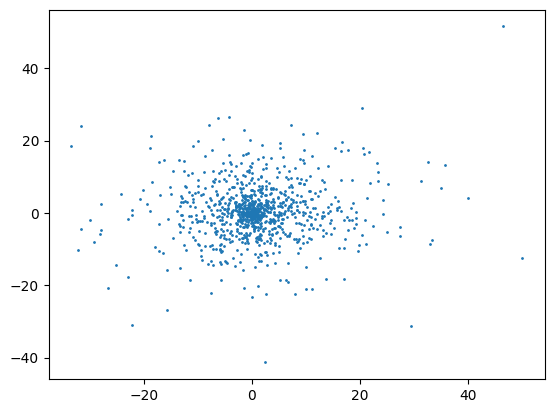

In [20]:
# NBVAL_SKIP
import matplotlib.pyplot as plt
# Make a scatter plot of the stars coordinates
plt.scatter(rubixdata.stars.coords[:,0], rubixdata.stars.coords[:,1], s=1)


## Step 3: Rotation

In the `config` we specify, how the galaxy should be orientated. In this example we want to orientate the galaxy `edge-on`. We plot the coordinates again and see that they are now rotated.

In [21]:
# NBVAL_SKIP
from rubix.core.rotation import get_galaxy_rotation
rotate = get_galaxy_rotation(config)

rubixdata = rotate(rubixdata)

2025-07-01 11:55:25,114 - rubix - DEBUG - Roataion Type found: edge-on
2025-07-01 11:55:25,116 - rubix - INFO - Rotating galaxy with alpha=90.0, beta=0.0, gamma=0.0
2025-07-01 11:55:25,116 - rubix - DEBUG - No rotation matrix provided, using Euler angles for rotation.


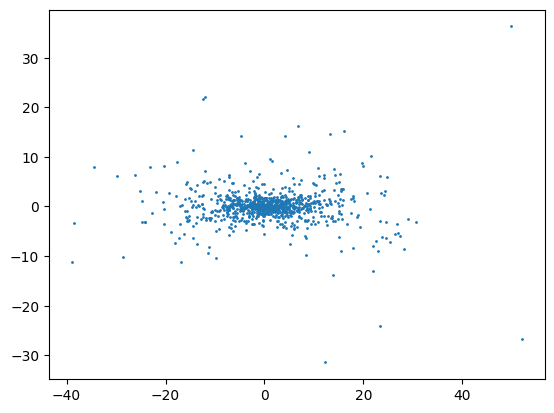

In [22]:
# Make a scatter plot of the stars coordinates after rotation
plt.scatter(rubixdata.stars.coords[:,0], rubixdata.stars.coords[:,1], s=1)

## Step 4: Filter particles

All particles outside field of view of the telescope are filtered. This has to be done, because we later bin the particles to the IFU grid and particles outside the arperture would make strange artefacts.

In [23]:
# NBVAL_SKIP
from rubix.core.telescope import get_filter_particles
filter_particles = get_filter_particles(config)

rubixdata = filter_particles(rubixdata)

2025-07-01 11:55:25,238 - rubix - INFO - Calculating spatial bin edges...
/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-07-01 11:55:25,249 - rubix - INFO - Getting cosmology...
2025-07-01 11:55:25,251 - rubix - INFO - Filtering particles outside the aperture...


## Step 5: Spaxel assignment

We have an telescope aperture and a spatial resolution, which results in a spatial grid for the IFU cube. We can now assign the stars particles to the different spaxels in the IFU cube, i.e. define to which spaxel the stellar light of each stars particle contribute.

In [24]:
# NBVAL_SKIP
from rubix.core.telescope import get_spaxel_assignment
bin_particles = get_spaxel_assignment(config)

rubixdata = bin_particles(rubixdata)

2025-07-01 11:55:25,268 - rubix - INFO - Calculating spatial bin edges...
2025-07-01 11:55:25,277 - rubix - INFO - Getting cosmology...
2025-07-01 11:55:25,278 - rubix - INFO - Assigning particles to spaxels...


## Step 7: Datacube calculation

This is the heart of the `pipeline`. Now we do the lookup for the spectrum for each stellar particle. For the simple stellar population model by `BruzualCharlot2003`, each stellar particle gets a spectrum assigned based on its age and metallicity. We weight the contribution of the stellar particle by its stellar mass and doppler shift it according to its line of sight position and redshift. The spectrum is resampled to the instruments wavelenght bins and optional dust attenuated. The spectrum is then added to the datacube at the correct spaxel position. This is repeated viajax. lax_scan for all particles.

In [25]:
# NBVAL_SKIP
from rubix.core.ifu import get_calculate_datacube_particlewise
calculate_datacube = get_calculate_datacube_particlewise(config)

rubixdata = calculate_datacube(rubixdata)

2025-07-01 11:55:25,303 - rubix - DEBUG - Method not defined, using default method: cubic


2025-07-01 11:55:25,312 - rubix - INFO - Calculating Data Cube (combined per‐particle)…
2025-07-01 11:55:25,789 - rubix - DEBUG - Datacube shape: (25, 25, 3721)


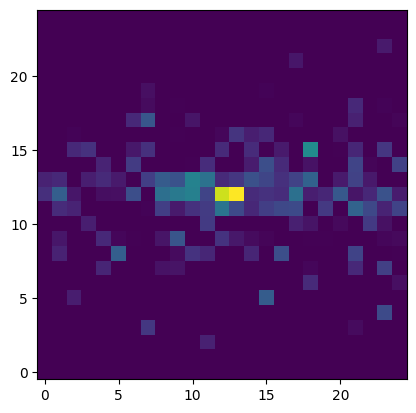

In [26]:
# NBVAL_SKIP
datacube = rubixdata.stars.datacube
img = datacube.sum(axis=2)
plt.imshow(img, origin="lower")

## Step 8: PSF

The instrument and the earth athmosphere affect the spatial resolution of the observation data and smooth in spatial dimention. To take this effect into account we convolve our datacube with a point spread function (PSF).

In [27]:
# NBVAL_SKIP
from rubix.core.psf import get_convolve_psf
convolve_psf = get_convolve_psf(config)

rubixdata = convolve_psf(rubixdata)

2025-07-01 11:55:26,021 - rubix - INFO - Convolving with PSF...


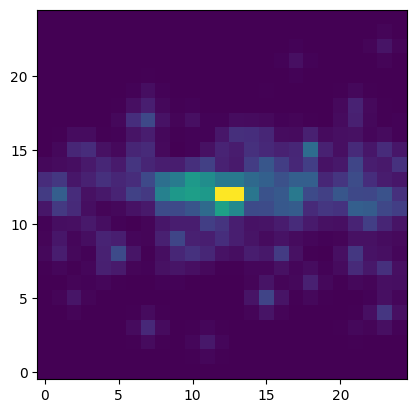

In [28]:
# NBVAL_SKIP
datacube = rubixdata.stars.datacube
img = datacube.sum(axis=2)
plt.imshow(img, origin="lower")

/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(


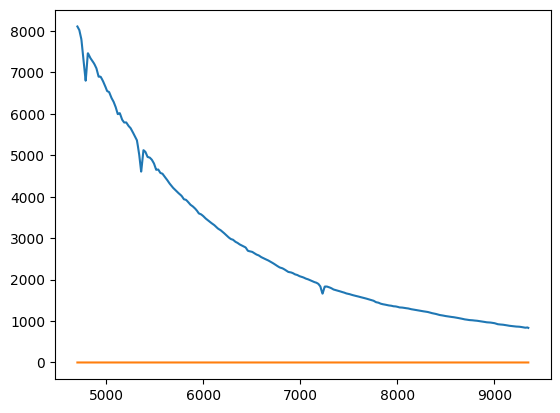

In [29]:
# NBVAL_SKIP
from rubix.core.pipeline import RubixPipeline 

pipe = RubixPipeline(config)
wave = pipe.telescope.wave_seq

plt.plot(wave, datacube[12,12,:])
plt.plot(wave, datacube[0,0,:])

## Step 9: LSF

The instrument affects the spectral resolution of the observation data and smooth in spectral dimention. To take this effect into account we convolve our datacube with a line spread function (LSF).

2025-07-01 11:55:26,247 - rubix - INFO - Convolving with LSF...


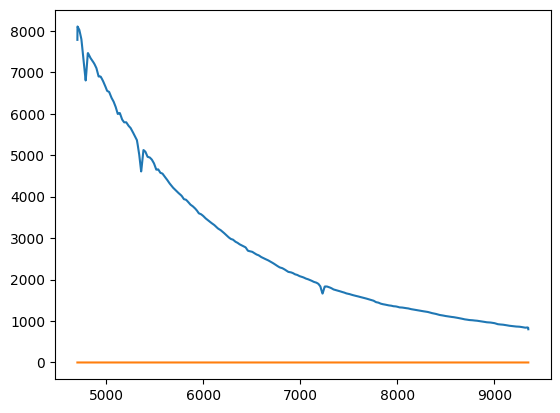

In [30]:
# NBVAL_SKIP
from rubix.core.lsf import get_convolve_lsf
convolve_lsf = get_convolve_lsf(config)

rubixdata = convolve_lsf(rubixdata)

plt.plot(wave, rubixdata.stars.datacube[12,12,:])
plt.plot(wave, rubixdata.stars.datacube[0,0,:])

## Step 10: Noise

Observational data are never noise-free. We apply noise to our mock-datacube to mimic real measurements.

2025-07-01 11:55:26,387 - rubix - INFO - Applying noise to datacube with signal to noise ratio: 1 and noise distribution: normal


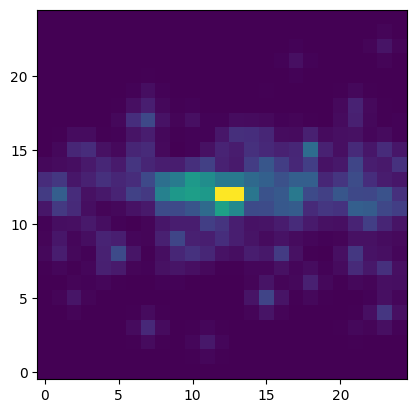

In [31]:
# NBVAL_SKIP
from rubix.core.noise import get_apply_noise
apply_noise = get_apply_noise(config)

rubixdata = apply_noise(rubixdata)

datacube = rubixdata.stars.datacube
img = datacube.sum(axis=2)
plt.imshow(img, origin="lower")

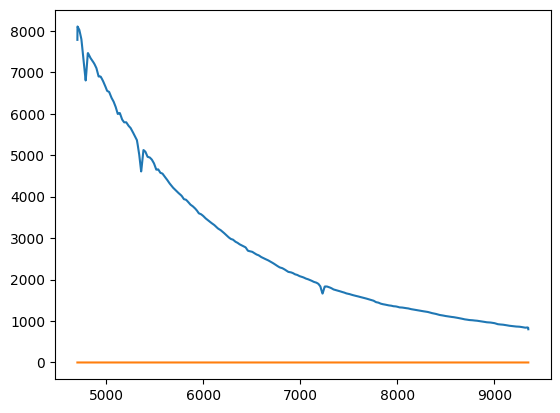

In [32]:
# NBVAL_SKIP
plt.plot(wave, rubixdata.stars.datacube[12,12,:])
plt.plot(wave, rubixdata.stars.datacube[0,0,:])

## DONE!

Congratulations, you have now created step by step your own mock-observed IFU datacube! Now enjoy playing around with the RUBIX pipeline and enjoy doing amazing science with RUBIX :)